                     Accuracy  Precision    Recall  F1 Score   ROC AUC
KNN                  0.620253   0.666667  0.846154  0.745763  0.480413
Decision Tree        0.645570   0.700000  0.807692  0.750000  0.570513
Logistic Regression  0.708861   0.737705  0.865385  0.796460  0.737892
SVM (RBF Kernel)     0.683544   0.690141  0.942308  0.796748  0.643162
Random Forest        0.658228   0.681159  0.903846  0.776860  0.726852


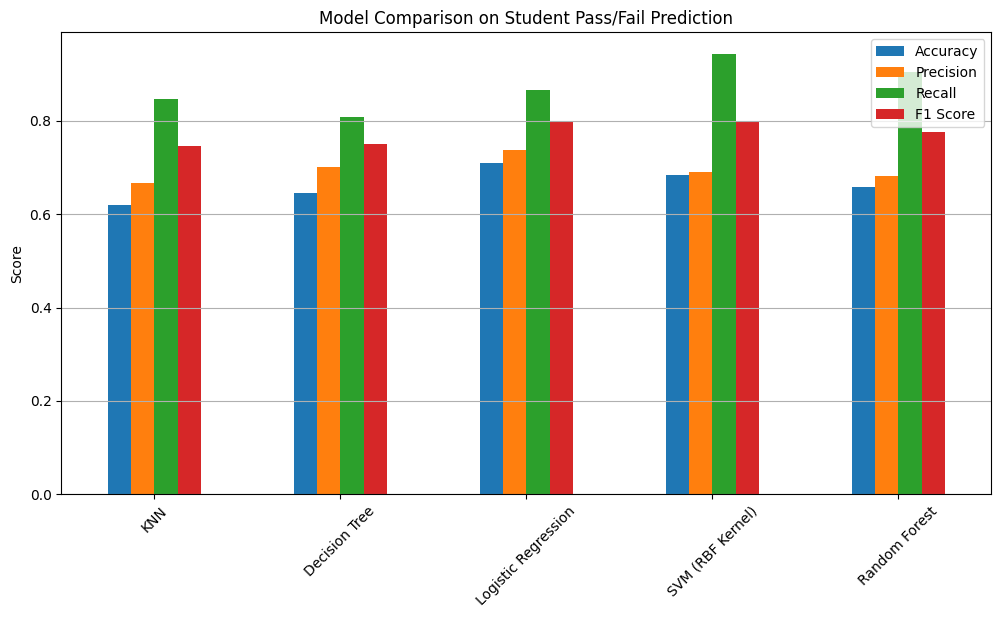

In [3]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# STEP 2: Load the local CSV (uploaded in Colab)
df = pd.read_csv("student-mat.csv", sep=";")  # or use 'student-por.csv'

# STEP 3: Binary Classification Target (Pass/Fail based on G3 >= 10)
df["pass"] = (df["G3"] >= 10).astype(int)

# Drop intermediate grades
df = df.drop(columns=["G1", "G2", "G3"])

# STEP 4: Encode Categorical Features
df_encoded = pd.get_dummies(df, drop_first=True)

# STEP 5: Split features and target
X = df_encoded.drop("pass", axis=1)
y = df_encoded["pass"]

# STEP 6: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 7: Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# STEP 8: Initialize Models
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# STEP 9: Train and Evaluate Each Model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else "N/A"
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1 Score": report["1"]["f1-score"],
        "ROC AUC": auc
    }

# STEP 10: Display Results
results_df = pd.DataFrame(results).T
print(results_df)

# STEP 11: Plotting Model Comparison
results_df[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Model Comparison on Student Pass/Fail Prediction")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()
